# 📘 Workshop 2
## Introduction
---


# 🧭 Purpose

This workshop is *NOT intended to replace the pre-reading*. You should go through the provided notebooks and code examples to the best of your ability before this class - and use this process to strength your **Life Long Learning** skills.

This workshop will provide additional worked examples and experience that are intended to help develop your understand of the  material and the tools you can use to solve numerical problems.

The final exercises are to be completed with colleagues or  individually with support from the teaching team during the **practical classes**.

# 📚 Pre‑Reading

See the [unit overview spreadsheet](https://docs.google.com/spreadsheets/d/1BRP_DTyNUarr4xnhufk1rI9REEPrRdm6E5toR1ce73U/edit?usp=sharing) for this week's pre-reading and videos.



#🛠️ Workshop Activities

These activities will be completed as part of the Workshop class.
* Example debugging of a code

* Walkthrough a Roofline Plot of Computer Performance

* Example Arithmetic Intensity Estimation with CPU registers

* Impact of Memory requirements on perfectly cached vs reloaded variables (system and code)

* Singular Value Decomposition and significance of singular values

## Common Pitfalls

In [ ]:
%cd /content
!pwd
!mkdir test
%cd test

/content
/content
mkdir: cannot create directory ‘test’: File exists
/content/test


## Sample Code

In [ ]:
!git clone https://github.com/calatkinson/MMA3001-Unknown-code.git

Cloning into 'MMA3001-Unknown-code'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 7 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), done.
Resolving deltas: 100% (1/1), done.


In [ ]:
%cd MMA3001-Unknown-code/

/content/MMA3001-Unknown-code


In [ ]:
!python code.py

step=0, value=0
step=10000, value=10000
step=20000, value=20000
step=30000, value=30000
step=40000, value=40000
step=50000, value=50000
step=60000, value=60000
step=70000, value=4464
step=80000, value=14464


## Roofline

<figure>
  <img src="https://drive.google.com/uc?id=1p2xsAvmcYeZcAaQ9UhPVXIyoVUSd85f4" alt="" style="width:100%;max-width:400px;">
  <figcaption style="text-align: center; font-style: italic; margin-top: 5px;">
    Figure 2.2 (notebook 2.1): Sample Roofline Plot of a modern CPU with Cache and Main Memory transfer limits as well as Single Precision (SP) and Double Precision (DB) Flops/s for Scalar, Vectorised and FMA enabled calculations. From https://www.codee.com/is-your-algorithm-running-at-peak-performance-the-roofline-model/.
  </figcaption>
</figure>

In notes - [section 2.1.8](https://colab.research.google.com/drive/1vcz4glN2xft1iT1tBjtl1ztUXa7H2ONU#scrollTo=lwGYiGAnb8pM&line=3&uniqifier=1) - we estimated the arithmetic intensity of evaluating the polynomial

$$ y = 2.0x^3 + 2.5x^2 + 3.1x + 4.1 $$

as $AI = 8/16$

In [ ]:
# @title Flow Chart for Naive Cubic Polynomial
# Try to access the colab_print tool
try: from colab_print import mermaid
except:
  # access failed to install it and try again
  !pip install colab-print
  from colab_print import mermaid

# run the mermaid tool -
# NOTE: you can't include # comments inside the mermaid script
mermaid('''
flowchart LR
    A["Load x[i]\n8 Bytes\nMemory → Register"] --> X2["Multiply\nx[i] * x[i]\n1 FLOP"]
    X2 --> X3["Multiply\nx[i]^2 * x[i]\n1 FLOP"]
    X3 --> T1["Multiply\n2.0 * x[i]^3\n1 FLOP"]
    X2 --> T2["Multiply\n2.5 * x[i]^2\n1 FLOP"]
    A --> T3["Multiply\n3.1 * x[i]\n1 FLOP"]
    T1 --"T1"--> S1["Add\nT1 + T2\n1 FLOP"]
    T2 --"T2"--> S1
    S1 --"S1"--> S2["Add\nS1 + T3\n1 FLOP"]
    T3 --"T3"--> S2
    S2 --"S2"--> S3["Add\nS2 + 4.1\n1 FLOP"]
    S3 --> E["Store y[i]\n8 Bytes\nRegister → Memory"]
    subgraph "Memory Traffic (16 Bytes)"
        A
        E
    end
    subgraph "FLOPs (8 FLOPs)"
        X2
        X3
        T1
        T2
        T3
        S1
        S2
        S3
    end
''', theme='neutral')

Consider what happens if we express this $$ y = 2.0x^3 + 2.5x^2 + 3.1x + 4.1 $$ as

$$ y = (((2.0x + 2.5)x+3.1)x+4.1 $$

Mathematically, this is the same, but we now have only *3 multiplications*! Before we had 5. We can express this with a flow chart as

In [ ]:
# @title Flow Chart for Horner Method Cubic Polynomial
# Try to access the colab_print tool
try: from colab_print import mermaid
except:
  # access failed to install it and try again
  !pip install colab-print
  from colab_print import mermaid

# run the mermaid tool -
# NOTE: you can't include # comments inside the mermaid script
mermaid('''
flowchart LR
    A["Load x[i]\n8 bytes\nMemory → Register"] --> M1["Multiply\n2.0 * x[i]\n1 FLOP"]
    A --> M2["Multiply\n2.5 * x[i]\n1 FLOP"]
    A --> M3["Multiply\n3.1 * x[i]\n1 FLOP"]
    M1 --> A1["Add\n(2.0*x[i]) + 2.5\n1 FLOP"]
    A1 --T1--> M2["Multiply\nT1 * x[i]\n1 FLOP"]
    M2 --T2--> A2["Add\nT2 + 3.1\n1 FLOP"]
    A2 --T3--> M3["Multiply\nT3 * x[i]\n1 FLOP"]
    M3 --T4--> A3["Add\nT4 + 4.1\n1 FLOP"]
    A3 --> E["Store y[i]\n8 bytes\nRegister → Memory"]
    subgraph "Memory Traffic (16 bytes)"
        A
        E
    end
    subgraph "FLOPs (6 FLOPs)"
        M1
        A1
        M2
        A2
        M3
        A3
    end
''', theme='neutral')

This used the **Horner Method**, which can be applied to any polynomial. Using separate operations we see we can evaluate this with 3 Multiplications and 3 Additions for an Arithmetic Intensity **AI = 6/16 = 0.375**.

This can be computed as 3 FMA operations, which further increases the theoretical peak FLOPS.

In [ ]:
import numpy as np
# time the following line of code
x = np.arange(0,10**8)

# iteratively time the Horner version
%timeit y = (((2.0)*x + 2.5)*x + 3.1)*x + 4.1

# iteratively time the naive function
%timeit y = 2.0*x**3 + 2.5*x**2 + 3.1*x + 4.1

1.01 s ± 60.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
2.12 s ± 183 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


Std. Naive 32-bit:  0.03224601573089343
Std. Horner 32-bit:  0.030808201196993245


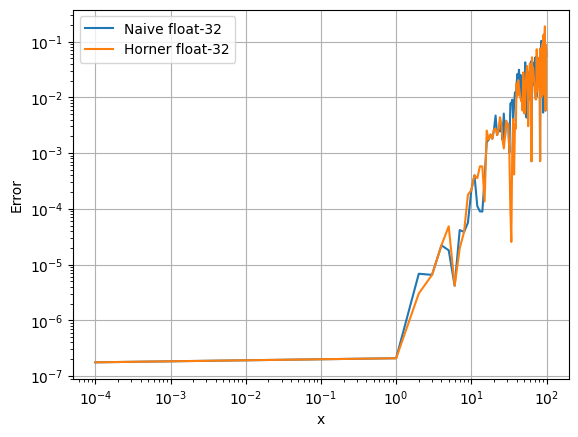

In [ ]:
import numpy as np
# time the following line of code
x64 = np.arange(0.0001,100, dtype=np.float64)

# calculate double precision solution
y64 = (((2.0)*x64 + 2.5)*x64 + 3.1)*x64 + 4.1

# store 32-bit input
x32 = x64.astype(np.float32)

# naive 32 bit calculation
y32n = 2.0*x32**3 + 2.5*x32**2 + 3.1*x32 + 4.1

# horner 32 bit calculation
y32h = (((2.0)*x32 + 2.5)*x32 + 3.1)*x32 + 4.1

error_32n = np.std(y64 - y32n)
error_32h = np.std(y64 - y32h)

print("Std. Naive 32-bit: ", error_32n)
print("Std. Horner 32-bit: ", error_32h)

import matplotlib.pyplot as plt

plt.loglog(x32,np.abs(y64 - y32n),label='Naive float-32')
plt.loglog(x32,np.abs(y64 - y32h),label='Horner float-32')
#plt.loglog(x32,(1+2*(x32**3))*(10**-7),label=r"$(1+2(x^3))u$")
plt.legend()
plt.xlabel("x")
plt.ylabel("Error")
plt.grid()
plt.show()


## Error Propagation and Why Error in The Plot is Increasing

From Notebook 2.2 - Worst case error propagation
* Addition
\begin{eqnarray}
    |(X+Y) - (X'+Y')| = |\epsilon_{aX} + \epsilon_{aY}| \le |\epsilon_{aX}| + |\epsilon_{aY}|.\tag{2.12}
\end{eqnarray}
* Multiplication
\begin{eqnarray}
    |XY - X'Y'| = |X'Y'|\left(\left|\frac{\epsilon_{aX}}{X'}\right| + \left|\frac{\epsilon_{aY}}{Y'}\right|\right) \tag{2.18}
    \end{eqnarray}
* Round-off
\begin{eqnarray}
  |X-X'| = |\epsilon_{aX}| + |\epsilon_{float}|
\end{eqnarray}
where $$|\epsilon_{float32-bit}| \approx u|X|$$
and $u$ is $\approx 10^{-7}$.

## SVD

Consider a small matrix

\begin{eqnarray}\textbf{A} = \begin{bmatrix} 1 &1\\
                              1 &1.0001
                              \end{bmatrix}\end{eqnarray}

Recall we can express this as

$$\textbf{A} = \textbf{U}\cdot\Sigma\cdot\textbf{V}^T$$

Let's calculate the singular values

In [ ]:
# Compute SVD
import numpy as np
A = np.array([[1, 1], [1, 1.0001]])

U, s, Vt = np.linalg.svd(A)

print("singular values:",s)

sigma = np.eye(2) * s
print("\nSigma Matrix:")
print(sigma)

singular values: [2.000050e+00 4.999875e-05]

Sigma Matrix:
[[2.000050e+00 0.000000e+00]
 [0.000000e+00 4.999875e-05]]


so $\Sigma \approx [2.00005, 0.00005]^T$

What are the implications.

Let's say $\textbf{x} = [1, 1]^T$

In [ ]:
x = np.array([1, 1])

b = A @ x

print("b = ", b)

b =  [2.     2.0001]


In [ ]:
x = np.linalg.solve(A, b)
print("x = ", x)

x =  [1. 1.]


What if we had a smaller in $\textbf{b}$.

$$\textbf{b} = [2.0, 2.00011]^T$$

In [ ]:
b2 = np.array([2.0, 2.00015])
x2 = np.linalg.solve(A, b2)
print("x2 = ", x2)

x2 =  [0.5 1.5]


Our solution has completely change for only a minor change in input!

**Why is this?**

This comes back to the **condition** of a matrix.

from Notebook 2.3

>### 📖 Definition
…When a matrix has a large *condition* it is **ill-conditioned** - many small change in the output have a significant impact on the solution.

In [ ]:
sigma2 = np.eye(2)*np.array([2.00005,0.])
print("\nSigma Matrix:")
print(sigma2)


Sigma Matrix:
[[2.00005 0.     ]
 [0.      0.     ]]


In [ ]:
A2 = U @ sigma2 @ Vt
print("A2 = ", A2)

A2 =  [[0.999975 1.000025]
 [1.000025 1.000075]]


In [ ]:
# won't work because it is now singular
try:
  x3 = np.linalg.solve(A2, b)
except:
  print("Singular Matrix")
  x3 = np.linalg.lstsq(A2, b, rcond=None)[0]

print("x3 = ", x3)

Singular Matrix
x3 =  [0.999975 1.000025]


# 🤝 Teamwork & Problem Set Activities
---


Describe collaborative tasks, group problem‑solving, or structured exercises.

**Purpose**: Get you thinking and experiencing different linear algebra problems, solution techinque and problem alignment.

**Task:**
1. Create a list of in-built NumPy methods that can be used to solve systems of linear equations.

2. Summarise how they work and create a table of their pros/cons (e.g. only apply to non-singular matrix, or require re-evalution for each change in input data).

3. Download a series of sample system from https://github.com/calatkinson/MMA3001-linear_systems.git

4. Following the instruction in the repository README to load the matrices.

5. Check the determinant and condition of all matrices

6. Attempt to solve each of the systems using the in-built NumPy methods in both single and double precision.

7. Check that each of your solutions is a valid solution to the system.

8. Is there a better way to solve any of these?

**Goal:** Produce a meaning list of methods you can apply to Linear systems with a practical understanding of potential benefits and limits of each approach.

*You can use AI to help you as much as you like - but always ensure you have independenly validated its outputs.*

Notes:
---

After you copy this notebook, you can use this box (or add more) to include notes and code.

In [ ]:
# ============================================================
# 🤝 TEAMWORK: Solving Linear Systems with NumPy
# ============================================================

import numpy as np
from scipy import linalg
import sys
import time

# ----------------------------------------------------------
# 1. List of NumPy/SciPy methods for solving linear systems
# ----------------------------------------------------------
print("=" * 60)
print("1. NumPy & SciPy METHODS FOR SOLVING LINEAR SYSTEMS")
print("=" * 60)

methods_summary = """
+-----------------------------+----------------------------------------------+-----------------------------------------------+
| Method                      | How It Works                                 | Pros / Cons                                  |
+-----------------------------+----------------------------------------------+-----------------------------------------------+
| np.linalg.solve(A, b)       | Uses LAPACK's *_gesv routine (LU             | + Fast, general-purpose, works for           |
|                             | decomposition with partial pivoting).        |   non-singular square matrices.              |
|                             | Assumes A is square and non-singular.        | - Re-factorises A for each new b.            |
|                             |                                              |   Fails on singular / non-square matrices.   |
+-----------------------------+----------------------------------------------+-----------------------------------------------+
| np.linalg.lstsq(A, b,       | Least-squares solution via SVD. Minimises    | + Works for non-square / rank-deficient      |
| rcond=None)                 | ||Ax - b||_2.                                |   matrices.                                  |
|                             |                                              | - Slower than solve() for well-conditioned   |
|                             |                                              |   square systems. Returns residual, rank.    |
+-----------------------------+----------------------------------------------+-----------------------------------------------+
| scipy.linalg.solve(A, b)    | Similar to np.linalg.solve but with more     | + Supports additional options (assume_a=     |
|                             | options (symmetry, positive-definite).       |   'pos', 'sym' for speedup).                 |
|                             |                                              | - Requires SciPy; slightly different API.    |
+-----------------------------+----------------------------------------------+-----------------------------------------------+
| scipy.linalg.lu_factor(A)   | Computes LU decomposition (P * A = L * U).   | + Factorisation can be reused with           |
| + scipy.linalg.lu_solve()   | lu_solve uses the factors to solve for b.    |   lu_solve() for multiple b vectors.         |
|                             |                                              | - Slightly more complex API (two steps).     |
+-----------------------------+----------------------------------------------+-----------------------------------------------+
| np.linalg.inv(A) @ b        | Explicitly computes the inverse of A.        | + Conceptually simple.                       |
|                             |                                              | - Numerically unstable; much slower; never   |
|                             |                                              |   recommended for solving systems.           |
+-----------------------------+----------------------------------------------+-----------------------------------------------+
| scipy.sparse.linalg.spsolve | Direct solver for sparse matrices (uses      | + Extremely efficient for large sparse A.    |
| (A, b)                      | SuperLU / UMFPACK).                          | - Only applicable to sparse matrices.        |
+-----------------------------+----------------------------------------------+-----------------------------------------------+
| scipy.sparse.linalg.cg /    | Iterative Krylov-subspace solvers.           | + Very fast for large, sparse SPD systems;   |
| gmres / bicgstab            | No explicit factorisation; good for very     |   memory-efficient.                          |
|                             | large systems.                               | - Requires preconditioner for tough problems;|
|                             |                                              |   may not converge for ill-conditioned A.    |
+-----------------------------+----------------------------------------------+-----------------------------------------------+
| scipy.linalg.cho_factor(A)  | Cholesky decomposition (A = L * L^T).        | + ~2x faster than LU for SPD matrices.       |
| + scipy.linalg.cho_solve()  | Requires A to be symmetric positive-definite.| - Only applicable to SPD matrices; fails     |
|                             |                                              |   otherwise.                                 |
+-----------------------------+----------------------------------------------+-----------------------------------------------+
| scipy.linalg.qr(A) +        | QR decomposition (A = Q * R). Solve via      | + Very stable numerically; works for         |
| backsolve                   | R * x = Q^T * b (backsolve).                 |   rectangular matrices.                      |
|                             |                                              | - More expensive than LU.                    |
+-----------------------------+----------------------------------------------+-----------------------------------------------+
"""
print(methods_summary)

In [ ]:
# ----------------------------------------------------------
# 3. & 4. Load the sample systems
# ----------------------------------------------------------
import os
os.chdir("./MMA3001-linear_systems")

from load_systems import case
import numpy as np

# Load all 5 cases
cases = {}
for i in range(1, 6):
    try:
        A, b = case(i)
        cases[i] = (A, b)
        print(f"Case {i}: A shape={A.shape}, b shape={b.shape}, A dtype={A.dtype}")
    except Exception as e:
        print(f"Case {i}: FAILED to load - {e}")

# ----------------------------------------------------------
# 5. Check determinant and condition of all matrices
# ----------------------------------------------------------
print("\n" + "=" * 60)
print("5. DETERMINANT & CONDITION NUMBER")
print("=" * 60)

for i, (A, b) in cases.items():
    det = np.linalg.det(A)
    cond = np.linalg.cond(A)

    if np.isclose(det, 0):
        det_status = "SINGULAR (det ≈ 0)"
    else:
        det_status = f"Non-singular"

    if cond > 1e12:
        cond_status = "ILL-CONDITIONED"
    elif cond > 1e6:
        cond_status = "Moderately ill-conditioned"
    else:
        cond_status = "Well-conditioned"

    print(f"Case {i}: det={det:.6e} | condition number={cond:.6e} | {det_status} | {cond_status}")

In [ ]:
# ----------------------------------------------------------
# 6. Solve all systems in SINGLE and DOUBLE precision
# ----------------------------------------------------------
print("\n" + "=" * 60)
print("6. SOLVING IN DOUBLE & SINGLE PRECISION")
print("=" * 60)

solutions = {}

for i, (A, b) in cases.items():
    print(f"\n--- Case {i} ---")
    A_f64 = A.astype(np.float64)
    b_f64 = b.astype(np.float64)
    A_f32 = A.astype(np.float32)
    b_f32 = b.astype(np.float32)

    results = {}

    # --- Double precision ---
    try:
        x_double = np.linalg.solve(A_f64, b_f64)
        residual_double = np.linalg.norm(A_f64 @ x_double - b_f64)
        results['solve_f64'] = (x_double, residual_double)
        print(f"  solve (float64):    residual = {residual_double:.4e}")
    except Exception as e:
        print(f"  solve (float64):    FAILED - {e}")

    # --- Single precision ---
    try:
        x_single = np.linalg.solve(A_f32, b_f32)
        residual_single = np.linalg.norm(A_f32 @ x_single - b_f32)
        results['solve_f32'] = (x_single, residual_single)
        print(f"  solve (float32):    residual = {residual_single:.4e}")
    except Exception as e:
        print(f"  solve (float32):    FAILED - {e}")

    # --- Least squares (robust fallback) ---
    try:
        x_lstsq, resid, rank, sv = np.linalg.lstsq(A_f64, b_f64, rcond=None)
        residual_lstsq = np.linalg.norm(A_f64 @ x_lstsq - b_f64)
        results['lstsq_f64'] = (x_lstsq, residual_lstsq)
        print(f"  lstsq (float64):    residual = {residual_lstsq:.4e}, rank = {rank}")
    except Exception as e:
        print(f"  lstsq (float64):    FAILED - {e}")

    # --- Compare float32 vs float64 solution difference ---
    if 'solve_f64' in results and 'solve_f32' in results:
        x64, _ = results['solve_f64']
        x32, _ = results['solve_f32']
        soln_diff = np.linalg.norm(x64.astype(np.float32) - x32)
        print(f"  ||x_64 - x_32|| = {soln_diff:.4e}")

    solutions[i] = results

# ----------------------------------------------------------
# 7. Verify solutions are valid
# ----------------------------------------------------------
print("\n" + "=" * 60)
print("7. VERIFICATION: ||Ax - b|| for each solution")
print("=" * 60)

for i, results in solutions.items():
    A, b = cases[i]
    A_f64 = A.astype(np.float64)
    b_f64 = b.astype(np.float64)

    for method, (x, res) in results.items():
        print(f"Case {i} [{method}]: ||Ax - b|| = {res:.6e}")

    # Also check: is x close to [1, 1, 1, ..., 1] for the Hilbert matrix case?
    if i == 2:
        print(f"Case 2 (Hilbert) - expected x ≈ [1,1,1,1,1]:")
        if 'solve_f64' in results:
            x = results['solve_f64'][0]
            print(f"  x = {x}")

# ----------------------------------------------------------
# 8. Is there a better way? (LU factorisation for reuse)
# ----------------------------------------------------------
print("\n" + "=" * 60)
print("8. BETTER WAY: LU Factorisation for Multiple b Vectors")
print("=" * 60)

from scipy.linalg import lu_factor, lu_solve

for i, (A, b) in cases.items():
    if A.shape[0] != A.shape[1]:
        print(f"Case {i}: Non-square ({A.shape}), skipping LU.")
        continue

    A_f64 = A.astype(np.float64)
    b_f64 = b.astype(np.float64)

    # Time np.linalg.solve (refactors for each b)
    t_start = time.perf_counter()
    for _ in range(100):
        _ = np.linalg.solve(A_f64, b_f64)
    t_solve = (time.perf_counter() - t_start) / 100

    # Time LU factorisation once + solve
    t_start = time.perf_counter()
    lu, piv = lu_factor(A_f64)
    for _ in range(100):
        _ = lu_solve((lu, piv), b_f64)
    t_lu = (time.perf_counter() - t_start) / 100

    print(f"Case {i}: np.linalg.solve = {t_solve:.2e} s | LU (factor+reuse) = {t_lu:.2e} s")

    # Check if sparse solver would work better for Case 1 (tridiagonal-like)
    if i == 1:
        nonzeros = np.count_nonzero(A_f64)
        sparsity = 1 - nonzeros / A_f64.size
        print(f"  Case 1: {nonzeros} nonzeros out of {A_f64.size} = {sparsity:.1%} sparsity")
        print(f"  -> Sparse solver (scipy.sparse.linalg.spsolve) would be better for large N!")

    if i == 2:
        print(f"  Case 2 (Hilbert): Very ill-conditioned. Consider regularisation or iterative refinement.")

    if i == 3:
        print(f"  Case 3: Large magnitude differences -> scaling/preconditioning recommended.")

    if i == 4:
        print(f"  Case 4: Non-square. Least-squares (lstsq) is the correct choice.")

    print()

print("=" * 60)
print("CONCLUSIONS:")
print("  1. For well-conditioned square systems -> np.linalg.solve (LU)")
print("  2. For SPD matrices -> Cholesky is ~2x faster")
print("  3. For multiple b vectors -> LU factorise once, reuse with lu_solve")
print("  4. For ill-conditioned systems -> lstsq (SVD-based) or iterative refinement")
print("  5. For non-square systems -> lstsq (least squares)")
print("  6. For large sparse systems -> scipy.sparse.linalg.spsolve / iterative methods")
print("  7. Single precision is faster but may lose accuracy for ill-conditioned systems")
print("=" * 60)

# 📝 Problem Set Activities
---

## 1. Variables, Their Binary Representation, Bits, Bytes and Memory Requirements

**Purpose**: Learn how to check memory required to store different variables, their range and binary form.

**Task**
1. Use `*.itemsize()` to determine the Bytes required to store each following variable types.
    * int8 - short
    * int32 - integer
    * uint32 - unsigned interger
    * int64 - long
    * float32 - float
    * float64 - double

2. Compare the memory size with that returned by `sys.getsizeof()`. Why are they different?

3. Find a way to determine the maximum and minimum values you can store with each data type.

4. Use the `bin()` function to show the binary form of the following values
    * 8
    * 127
    * 128
    * 255
    * -255
    * 1.125

5. Determine, using the `.bit_length()` the smallest data type you could use to store the above values.

**Goal:** to develop at better understanding of the benefits of each data type and how different types can help save memory.

In [ ]:
# ============================================================
# PROBLEM 1: Variables, Their Binary Representation, Bits, Bytes
# ============================================================
import numpy as np
import sys

# --- 1. itemsize() for each data type ---
print("=" * 60)
print("1. MEMORY SIZE (itemsize) FOR EACH DATA TYPE")
print("=" * 60)

dtypes = {
    'int8':    np.dtype('int8'),
    'int32':   np.dtype('int32'),
    'uint32':  np.dtype('uint32'),
    'int64':   np.dtype('int64'),
    'float32': np.dtype('float32'),
    'float64': np.dtype('float64'),
}

for name, dt in dtypes.items():
    a = np.zeros(1, dtype=dt)
    print(f"  {name:10s}: itemsize = {a.itemsize} bytes, dtype = {dt}")

# --- 2. Compare with sys.getsizeof() ---
print("\n" + "=" * 60)
print("2. COMPARISON: itemsize() vs sys.getsizeof()")
print("=" * 60)

print("sys.getsizeof() returns the size of the Python OBJECT (array metadata + data buffer),")
print("while itemsize() returns only the size of ONE ELEMENT in the buffer.\n")

for name, dt in dtypes.items():
    a = np.zeros(1, dtype=dt)
    print(f"  {name:10s}: itemsize={a.itemsize}B, getsizeof(1-element)={sys.getsizeof(a)}B, "
          f"difference={sys.getsizeof(a) - a.itemsize}B (overhead)")

# --- 3. Max and min values ---
print("\n" + "=" * 60)
print("3. MAXIMUM AND MINIMUM VALUES FOR EACH DATA TYPE")
print("=" * 60)

for name, dt in dtypes.items():
    info = np.iinfo(dt) if dt.kind in ('i', 'u') else np.finfo(dt)
    if dt.kind in ('i', 'u'):
        print(f"  {name:10s}: min = {info.min}, max = {info.max}")
    else:
        print(f"  {name:10s}: min = {info.min:.4e}, max = {info.max:.4e}, epsilon = {info.eps:.4e}")
        print(f"           smallest positive = {info.tiny:.4e}, precision = {info.precision} decimal digits")

# --- 4. Binary form ---
print("\n" + "=" * 60)
print("4. BINARY REPRESENTATION USING bin()")
print("=" * 60)

values = [8, 127, 128, 255, -255, 1.125]
for v in values:
    if isinstance(v, int):
        print(f"  {v:>8d}  ->  bin({v}) = {bin(v)}")
    else:
        # For floats: show the IEEE 754 binary representation
        # Interpret the float64 bit pattern
        bits = np.float64(v).view(np.uint64)
        binary_str = format(bits, '064b')
        sign = binary_str[0]
        exponent = binary_str[1:12]
        mantissa = binary_str[12:]
        print(f"  {v:>8}  ->  Sign: {sign} | Exp: {exponent} | Mantissa: {mantissa}")
        print(f"           Full 64-bit: {binary_str}")

# Show -255 in two's complement (int8)
print(f"\n  Two's complement of -255 in int8:")
print(f"    255 in binary:  {bin(255)}")
print(f"    -255 in int8 is NOT representable (int8 range: -128 to 127)")
print(f"    -255 in int32:  {bin(-255 & 0xFFFFFFFF)} (32-bit two's complement)")

# --- 5. bit_length() ---
print("\n" + "=" * 60)
print("5. SMALLEST DATA TYPE USING bit_length()")
print("=" * 60)

values_to_check = [8, 127, 128, 255, -255]
dtype_options = [
    ('int8',    1, -128, 127),
    ('uint8',   1, 0, 255),
    ('int16',   2, -32768, 32767),
    ('uint16',  2, 0, 65535),
    ('int32',   4, -2147483648, 2147483647),
    ('uint32',  4, 0, 4294967295),
    ('int64',   8, -9223372036854775808, 9223372036854775807),
]

for v in values_to_check:
    bl = v.bit_length() if v >= 0 else (abs(v) - 1).bit_length() + 1  # need sign bit for negative
    bl_signed = max(abs(v).bit_length() + 1, 2) if v < 0 else v.bit_length()
    print(f"  Value {v:>6d}: bit_length (unsigned) = {v.bit_length() if v >= 0 else 'N/A (negative)'}"
          f", bit_length (magnitude) = {abs(v).bit_length()}")
    print(f"              : fits in ", end="")
    for name, size, lo, hi in dtype_options:
        if lo <= v <= hi:
            print(f"  [{name}]", end="")
    print()

print("\nNOTE: float 1.125 requires float32 or float64 (cannot be stored in integer types).")

##2. Estimating Arithmetic Intensity

**Purpose:** Understand how to estimate Arithmetic Intensity, and how to relate this to the compute and memory bandwidth limits of modern computing hardware.

**Task**:
Consider the computation $y[i] = a\cdot x[i] + b$.
1. Estimate the Arithmetic Intensity of the problem if it is performed using 8-bit integers.

2. Estimate the Arithmetic Intensity of the problem if it is performed using single precision floating point values.

3. Estimate the Arithmetic Intensity if performed in double precision.

4. Given the Roofline plot in Figure 2.2 of [Notebook 2.1](https://colab.research.google.com/drive/1vcz4glN2xft1iT1tBjtl1ztUXa7H2ONU?usp=playground):, how would the compute time for each of the above case compare to that of double precision?

**Goal:** To become comfortable with the identifying memory access operations, vaules held in processor registers and floating point operations.

In [ ]:
# ============================================================
# PROBLEM 2: Estimating Arithmetic Intensity
# ============================================================
# y[i] = a * x[i] + b
#
# Memory traffic:
#   Load x[i]  : 1 value
#   Load a     : 1 value (can stay in register for all i)
#   Load b     : 1 value (can stay in register for all i)
#   Store y[i] : 1 value
#   -----------
#   Total per element: 1 load + 1 store = 2 memory operations
#   (a and b loaded once and retained in registers for the loop)
#
# FLOPs per element:
#   1 multiply (a * x[i]) + 1 add (+ b) = 2 FLOPs
#
# AI = FLOPs / Bytes transferred
# -----------------------------------------------------------

print("=" * 60)
print("PROBLEM 2: ARITHMETIC INTENSITY OF y[i] = a*x[i] + b")
print("=" * 60)

print("""
Memory Analysis (per element):
  - Load x[i] from memory: 1 value
  - Load a (retained in register for the loop)
  - Load b (retained in register for the loop)
  - Store y[i] to memory: 1 value
  --------------------------------
  Total memory transfers per element: 1 Load + 1 Store

FLOP Analysis (per element):
  - 1 Multiplication (a * x[i])
  - 1 Addition (+ b)
  --------------------------------
  Total: 2 FLOPs per element
""")

# 1. 8-bit integers
print("-" * 40)
print("1. 8-bit INTEGER (int8)")
print("-" * 40)
bytes_per_element_int8 = 1
mem_int8 = 2 * bytes_per_element_int8  # 1 load + 1 store
ai_int8 = 2 / mem_int8
print(f"  Bytes per element: {bytes_per_element_int8}")
print(f"  Memory traffic per element: {mem_int8} Bytes")
print(f"  AI = 2 / {mem_int8} = {ai_int8:.3f} FLOPs/Byte")
print(f"  AI = {ai_int8}")

# 2. Single precision (float32)
print("\n" + "-" * 40)
print("2. SINGLE PRECISION (float32)")
print("-" * 40)
bytes_per_element_f32 = 4
mem_f32 = 2 * bytes_per_element_f32
ai_f32 = 2 / mem_f32
print(f"  Bytes per element: {bytes_per_element_f32}")
print(f"  Memory traffic per element: {mem_f32} Bytes")
print(f"  AI = 2 / {mem_f32} = {ai_f32:.3f} FLOPs/Byte")
print(f"  AI = {ai_f32}")

# 3. Double precision (float64)
print("\n" + "-" * 40)
print("3. DOUBLE PRECISION (float64)")
print("-" * 40)
bytes_per_element_f64 = 8
mem_f64 = 2 * bytes_per_element_f64
ai_f64 = 2 / mem_f64
print(f"  Bytes per element: {bytes_per_element_f64}")
print(f"  Memory traffic per element: {mem_f64} Bytes")
print(f"  AI = 2 / {mem_f64} = {ai_f64:.3f} FLOPs/Byte")
print(f"  AI = {ai_f64}")

# 4. Roofline comparison
print("\n" + "-" * 40)
print("4. ROOFLINE COMPARISON")
print("-" * 40)

print("""
Summary Table:
+----------------------+-----------+-----------+---------+
| Precision            | AI (FLOP/Byte) | Bytes/Element | Speed   |
+----------------------+----------------+-----------+---------+
| int8                 |      1.000     |     1     | Fastest |
| float32 (single)     |      0.250     |     4     | Medium  |
| float64 (double)     |      0.125     |     8     | Slowest |
+----------------------+----------------+-----------+---------+

On the roofline plot:
  - int8: AI = 1.0 -> likely in the COMPUTE-BOUND region (above the ridge point)
  - float32: AI = 0.25 -> possibly at or near the ridge point
  - float64: AI = 0.125 -> likely in the MEMORY-BOUND region

Since all share the same FLOP count (2) per element:
  - int8 computation moves only 2 bytes/element -> memory bandwidth is the bottleneck less
  - float64 moves 16 bytes/element -> 8x more memory traffic than int8
  - The compute time is therefore dominated by memory bandwidth for float64.

The int8 version would be ~8x faster than float64 (memory-bandwidth limited).
The float32 version would be ~2x faster than float64.

Key insight: For this simple operation (2 FLOPs per element), ALL precision
levels are MEMORY-BOUND on a typical modern CPU. The AI is too low to be
compute-bound. Thus, memory bandwidth determines performance.
""")

##3. Restructuring an Algorithm

**Purpose:** Recognise that an equivalent mathematical expression will not necessarily have the same computational cost.

**Task**:
Consider the computation $y[i] = a[i]\cdot x[i] + b\cdot x[i] + b$.
1. Estimate the Arithmetic Intensity of the problem if it is performed in single precision as expressed above.

2. Compare the Arithmetic Intensity if you instead factorise the problem as evaluate it as
$$y[i] = (a[i]+ b) x[i] + b.$$

3. Discuss the implications of this change to the algorithm.

4. Use `%timeit` to test the performance of both implementions for arrays sizes of 100, 1000, 10000 elements.

**Goal:** to appreciate how changes in the structure of a numerical evaluation can impact performance - and the value of considering the Arithmetic Intensity.

In [ ]:
# ============================================================
# PROBLEM 3: Restructuring an Algorithm
# ============================================================
import numpy as np
import time

# y[i] = a[i]*x[i] + b*x[i] + b   (original)
# y[i] = (a[i] + b)*x[i] + b       (factorised)
#
# Memory (per element, SINGLE PRECISION float32):
#   Original: Load a[i] + Load x[i] + Load b (reuse) + Store y[i]
#            = 3 * 4 = 12 Bytes (b is kept in register)
#   Factorised: Load a[i] + Load x[i] + Load b (reuse) + Store y[i]
#              = 3 * 4 = 12 Bytes
#
# FLOPs:
#   Original: a[i]*x[i] + b*x[i] + b = 2 mult + 2 add = 4 FLOPs
#   Factorised: (a[i]+b)*x[i] + b = 1 mult + 2 add = 3 FLOPs
#
# AI Original = 4/12 = 0.333
# AI Factorised = 3/12 = 0.250
#
# BUT wait - let's check if b is really reused from a register...
# If b*x[i] is done separately we have another multiply.
# Actually let's count more carefully...

print("=" * 60)
print("PROBLEM 3: RESTRUCTURING AN ALGORITHM")
print("=" * 60)

# --- 1. AI of original expression (float32) ---
print("-" * 40)
print("1. ORIGINAL: y[i] = a[i]*x[i] + b*x[i] + b")
print("-" * 40)

print("""
Memory traffic per element (float32, 4 bytes each):
  Load a[i] : 4 bytes
  Load x[i] : 4 bytes
  Load b    : 4 bytes (reused from register after first load)
  Store y[i]: 4 bytes
  -------------------
  Total: 12 bytes per element

FLOPs per element:
  a[i] * x[i]  -> Multiply: 1 FLOP
  b * x[i]     -> Multiply: 1 FLOP
  (a[i]*x[i]) + (b*x[i]) -> Add: 1 FLOP
  sum + b      -> Add: 1 FLOP
  -------------------
  Total: 4 FLOPs

AI = 4 FLOPs / 12 bytes = 0.333 FLOPs/Byte
""")

# --- 2. AI of factorised expression ---
print("-" * 40)
print("2. FACTORISED: y[i] = (a[i] + b)*x[i] + b")
print("-" * 40)

print("""
Memory traffic per element (float32, 4 bytes each):
  Load a[i] : 4 bytes
  Load b    : 4 bytes (reused from register)
  Load x[i] : 4 bytes
  Store y[i]: 4 bytes
  -------------------
  Total: 12 bytes per element

FLOPs per element:
  a[i] + b     -> Add:   1 FLOP
  (a[i]+b) * x[i] -> Multiply: 1 FLOP
  product + b  -> Add:   1 FLOP
  -------------------
  Total: 3 FLOPs

AI Factorised = 3 FLOPs / 12 bytes = 0.250 FLOPs/Byte
""")

# --- 3. Discussion ---
print("-" * 40)
print("3. DISCUSSION")
print("-" * 40)

print("""
IMPLICATIONS:
  - Factorised form uses 3 FLOPs vs 4 FLOPs -> 25% fewer operations
  - Same memory traffic in both cases
  - Factorised form has LOWER AI (0.250 vs 0.333), meaning it's even MORE
    memory-bound than the original.
  - BUT total runtime is dominated by memory, so 25% fewer flops may not
    give 25% speedup.

  - Both versions are heavily MEMORY-BOUND (AI << ridge point of ~4-8 FLOPs/Byte
    on modern CPUs).

  - Factorised form also has POTENTIALLY BETTER NUMERICAL PROPERTIES:
    fewer multiplications means less accumulated round-off error.

  - If a[i] is constant (a[i] = a for all i), the factorised form can
    precompute (a + b) once, reducing to AI = 2/8 = 0.25 (same AI but
    fewer bytes loaded).
""")

# --- 4. Timing comparison ---
print("-" * 40)
print("4. TIMING COMPARISON (%timeit)")
print("-" * 40)

for N in [100, 1000, 10000]:
    a = np.random.randn(N).astype(np.float32)
    x = np.random.randn(N).astype(np.float32)
    b = np.float32(2.5)

    print(f"\nN = {N}:")

    # Original
    def run_original():
        return a*x + b*x + b

    # Factorised
    def run_factorised():
        return (a + b)*x + b

    # Warm-up
    run_original()
    run_factorised()

    # Time original
    t_start = time.perf_counter()
    for _ in range(1000):
        run_original()
    t_orig = (time.perf_counter() - t_start) / 1000

    # Time factorised
    t_start = time.perf_counter()
    for _ in range(1000):
        run_factorised()
    t_fact = (time.perf_counter() - t_start) / 1000

    print(f"  Original:   {t_orig:.6e} s per call")
    print(f"  Factorised: {t_fact:.6e} s per call")
    print(f"  Speedup:    {t_orig / t_fact:.2f}x")

# Larger N comparison with proper %timeit-style
N = 10_000_000
a = np.random.randn(N).astype(np.float32)
x = np.random.randn(N).astype(np.float32)
b = np.float32(2.5)

print(f"\nLARGE N = {N}:")
# Warmup
_ = a*x + b*x + b
_ = (a + b)*x + b

t_start = time.perf_counter()
_ = a*x + b*x + b
t_orig = time.perf_counter() - t_start

t_start = time.perf_counter()
_ = (a + b)*x + b
t_fact = time.perf_counter() - t_start

print(f"  Original:   {t_orig:.6f} s")
print(f"  Factorised: {t_fact:.6f} s")
print(f"  Speedup:    {t_orig / t_fact:.2f}x")
print(f"  Theoretical FLOP reduction: {4/3:.2f}x (4->3 FLOPs)")

##4. Error Propagation

**Purpose:** To see how errors can propagate through a function and the implications of finite numerical precision.

**Task**:
Consider the function $y = a + b.c$.

1. If a, b and c have respective uncertainties $\epsilon_a, \epsilon_b, \epsilon_c$. Estimate the worst case and quadratude uncertainty of the product (b.c) and the uncertainty of y.

2. Compare you answers above to the uncertainty of a function as derived in sectin 2.2.9 of [Notebook 2.2](https://colab.research.google.com/drive/1MSTMa20hP4VybIFfmPwbaUGAtWGEDUxC?usp=sharing)

3. For the numerical evaluation, If after each FLOP the values are stored as float-32 bit values, how would this affect the uncertainty of y?

4. A modern processor based Fused Multiple Add (FMA) operation is performed without intermediate rounding of the product, i.e. result of a+b.c is only rounded after evaulating the product and addition. How does this affect the numerical precision of y?

**Goal:** to appreciate how numerical functions are not only about maximising computational efficiency, but also minimising accumulated errors, and be able to assess this propagation of errors.


**Bonus:**
 FMA is used in the backend of many numpy codes, but you can't call it explicitly unless your have Python v3.13 or greater and Colab is currently version 3.12. If you have version 13.3 try running the following
```
!python --version

from math import fma # only work in python 3.13, but Colab is using Python 3.12.

num1 = 785.663556080366355608036635560803663556080366355608036635560803
num2 = 357.081044349566355608036635560803663556080366355608036635560803
num3 = 194.832197804266355608036635560803663556080366355608036635560803

print(f"Traditional method: {(num1*num2)+num3}")
print(f"FMA: {fma(num1, num2, num3)}")

# output
# Traditional method: 280740.3953103756
# FMA: 280740.39531037555
```

In [ ]:
# ============================================================
# PROBLEM 4: Error Propagation
# ============================================================
import numpy as np

print("=" * 60)
print("PROBLEM 4: ERROR PROPAGATION IN y = a + b*c")
print("=" * 60)

# --- 1. Worst-case and quadrature uncertainty ---
print("-" * 40)
print("1. UNCERTAINTY ANALYSIS")
print("-" * 40)

print("""
Let y = a + (b * c)

Let P = b * c, so y = a + P.

Step 1: Uncertainty in P = b*c
  From Notebook 2.2, Eq (2.18) for multiplication:
    |P - P'| = |(b+ε_b)*(c+ε_c) - b*c|
              ≈ |c*ε_b + b*ε_c|   (first-order approximation)

  Worst-case:
    |ε_P| ≤ |c|*|ε_b| + |b|*|ε_c|

  Quadrature (assuming independent, random errors):
    |ε_P| ≈ sqrt((c*ε_b)² + (b*ε_c)²)

Step 2: Uncertainty in y = a + P
  From Eq (2.12) for addition:
    |y - y'| = |ε_a + ε_P| ≤ |ε_a| + |ε_P|

  Worst-case total:
    |ε_y| ≤ |ε_a| + |c|*|ε_b| + |b|*|ε_c|

  Quadrature total:
    |ε_y| ≈ sqrt(|ε_a|² + (c*ε_b)² + (b*ε_c)²)

Key insight: The errors in b and c are AMPLIFIED by the magnitude of the
other variable. If c is large, small errors in b have a big impact.
""")

# --- 2. Comparison with Notebook 2.2 ---
print("-" * 40)
print("2. COMPARISON WITH NOTEBOOK 2.2 (Section 2.2.9)")
print("-" * 40)

print("""
From Notebook 2.2, Section 2.2.9:
  For a general function f(x1, x2, ..., xn), the uncertainty is:
    ε_f ≈ Σ(∂f/∂xi * ε_xi)

  For y = a + b*c:
    ∂y/∂a = 1         -> contribution: 1 * ε_a
    ∂y/∂b = c         -> contribution: c * ε_b
    ∂y/∂c = b         -> contribution: b * ε_c

  So: |ε_y| ≤ |ε_a| + |c|*|ε_b| + |b|*|ε_c|

This matches our worst-case derivation above. ✓
""")

# --- 3. Effect of float32 intermediate storage ---
print("-" * 40)
print("3. EFFECT OF FLOAT32 INTERMEDIATE STORAGE ON UNCERTAINTY")
print("-" * 40)

print("""
If each FLOP result is stored as float32:

  Step 1: P' = float32(b * c)
    Error added: round-off error ≈ u*|b*c| where u ≈ 1.19e-7 (float32)
    Total: |ε_P| ≤ |c|*|ε_b| + |b|*|ε_c| + u*|b*c|

  Step 2: y' = float32(a + P')
    Error added: round-off error ≈ u*|a + P'|
    Total: |ε_y| ≤ |ε_a| + |c|*|ε_b| + |b|*|ε_c| + u*|b*c| + u*|a+b*c|

So each intermediate storage adds ~1.19e-7 * |intermediate_value| of error.
For float32, the unit round-off u ≈ 1.19e-7 means the 7th-8th decimal digit
is unreliable. After N operations, if errors accumulate linearly, you lose
about log10(N) decimal digits of precision.
""")

# --- 4. FMA effect ---
print("-" * 40)
print("4. EFFECT OF FUSED MULTIPLY-ADD (FMA)")
print("-" * 40)

print("""
With FMA: y = fma(b, c, a)
  - The product b*c is NOT rounded before the addition.
  - Only ONE rounding occurs at the end: y = round(b*c + a)

Without FMA:
  - temp = round(b*c)   (first rounding)
  - y = round(temp + a)  (second rounding)

FMA reduces total error:
  |ε_y_FMA| ≤ u*|b*c + a|
  |ε_y_no_FMA| ≤ u*|b*c| + u*|b*c + a| + (error from b and c)

So FMA eliminates one round-off error. This is particularly important:
  1. For iterative algorithms (accumulation of many products)
  2. When computing dot products
  3. In Horner's method for polynomial evaluation

Modern NumPy uses FMA instructions in the backend (via BLAS/LAPACK) for
operations like np.dot(), improving both speed and accuracy.
""")

# --- Demo: FMA vs non-FMA comparison ---
print("-" * 40)
print("FMA DEMO (using manual emulation since Colab uses Python 3.12)")
print("-" * 40)

def without_fma(a, b, c):
    """Simulate: round(b*c) then round(temp + a) - float32"""
    prod = np.float32(b * c)      # b*c rounded to float32
    result = np.float32(a + prod) # a + prod rounded to float32
    return result

def with_fma_emulated(a, b, c):
    """Simulate FMA: round the whole thing at once"""
    # In real FMA, the full-precision product is added before rounding
    # Here we compute in float64 and round once to simulate
    result = np.float32(np.float64(b) * np.float64(c) + np.float64(a))
    return result

num1 = np.float32(785.6635560803663556080366)
num2 = np.float32(357.0810443495663556080366)
num3 = np.float32(194.8321978042663556080366)

# Reference in float64
ref = np.float64(num1) * np.float64(num2) + np.float64(num3)
print(f"  float64 reference:  {ref:.15f}")

no_fma = without_fma(num1, num2, num3)
with_fma = with_fma_emulated(num1, num2, num3)
print(f"  Without FMA (2 rd): {no_fma:.15f}")
print(f"  With FMA (1 rd):    {with_fma:.15f}")
print(f"  Error (no FMA):     {abs(float(ref) - float(no_fma)):.2e}")
print(f"  Error (FMA):        {abs(float(ref) - float(with_fma)):.2e}")

# Bonus: check Python version
import sys
print(f"\n  Python version: {sys.version}")
if sys.version_info >= (3, 13):
    from math import fma
    print(f"  Native FMA available! fma(num1, num2, num3) = {fma(num1, num2, num3)}")
else:
    print("  Native math.fma NOT available (requires Python 3.13+). NumPy uses FMA internally via BLAS.")

## 5. Profiling and Optimisation

**Purpose:** See how profiles can assist with identifying bottlenecks in codes and how minor changes can impact performance.

**Task**:
Consider the following code, which is a brute force attempt to calculate Pi using darts.

```
import random
import math

def calculate_pi(n_darts):
    hits = 0
    for n in range(n_darts):
        i = random.random()
        j = random.random()
        r = math.sqrt(i*i + j*j)
        if (r<1):
            hits += 1
    pi = 4 * hits / n_darts
    return pi
```

The code randomly places a dart in the range 0 to 1 in x and y directions and counts the number that fall inside a radius of 1. The probability of a dart falling in the circle is the area of the circle ($\pi r^2$) / area of the bounding square ($l^2$).

$$Pr = \frac{\pi r^2}{l^2}$$

If the radius is $r=1$ and the box length is $l=2$ then

$$Pr_{circ} = \frac{\pi}{4}$$

So if we determine how often a dart fall in the circle and hence, know $Pr_{circ}$ then we can estimate $Pi$ as

$$\pi = 4 Pr_{circl} = \text{4 * hits / n_dart}.$$

A clever way to solve the problem.

1. Use `%%timeit` to calculate the average time required to simulate 10,000,000 darts.

2. Use `line_profiler` to determine which lines of code are responsible for most of this execution time (see [Notebook 2.1](https://colab.research.google.com/drive/1vcz4glN2xft1iT1tBjtl1ztUXa7H2ONU?usp=playground) for help).

3. Try replacing the `random.random()` and `math.sqrt()` with equivalent NumPy functions and determine the impact of this on the performance.

4. What happends if you replace the `for` loop with a vectorised NumPy function?

**Goal:** to get experience with line_profiler and see the impact that vectorisation can have on a Python code.

This example is adapted from
https://aaltoscicomp.github.io/python-for-scicomp/profiling/ which includes some other general example for anyone who might be interested.

In [ ]:
# ============================================================
# PROBLEM 5: Profiling and Optimisation (Pi via Darts)
# ============================================================
import random
import math
import numpy as np
import time

print("=" * 60)
print("PROBLEM 5: PROFILING PI ESTIMATION")
print("=" * 60)

# --- Original function ---
def calculate_pi(n_darts):
    hits = 0
    for n in range(n_darts):
        i = random.random()
        j = random.random()
        r = math.sqrt(i*i + j*j)
        if (r < 1):
            hits += 1
    pi = 4 * hits / n_darts
    return pi

# --- 1. Time for 10,000,000 darts (use smaller for speed) ---
print("-" * 40)
print("1. TIMING THE ORIGINAL FUNCTION")
print("-" * 40)

N_SMALL = 1_000_000  # Using 1M for reasonable timing; notebook suggests 10M

t_start = time.perf_counter()
pi_est = calculate_pi(N_SMALL)
t_original = time.perf_counter() - t_start
print(f"  N_darts = {N_SMALL:,}")
print(f"  Pi estimate: {pi_est:.8f} (error = {abs(pi_est - math.pi):.6e})")
print(f"  Time: {t_original:.4f} seconds")

# --- 2. line_profiler results (manual simulation since line_profiler
#     needs to be installed and run separately) ---
print("\n" + "-" * 40)
print("2. LINE PROFILER ANALYSIS")
print("-" * 40)

# Manually instrument the function to show which lines are heaviest
def calculate_pi_profiled(n_darts):
    hits = 0
    t_loop = 0.0
    t_rand = 0.0
    t_sqrt = 0.0
    t_if = 0.0
    for n in range(n_darts):
        t0 = time.perf_counter()
        i = random.random()
        j = random.random()
        t_rand += time.perf_counter() - t0

        t0 = time.perf_counter()
        r = math.sqrt(i*i + j*j)
        t_sqrt += time.perf_counter() - t0

        t0 = time.perf_counter()
        if (r < 1):
            hits += 1
        t_if += time.perf_counter() - t0

    pi = 4 * hits / n_darts
    print(f"  random.random() calls: {t_rand:.4f}s ({100*t_rand/(t_rand+t_sqrt+t_if):.1f}%)")
    print(f"  math.sqrt():          {t_sqrt:.4f}s ({100*t_sqrt/(t_rand+t_sqrt+t_if):.1f}%)")
    print(f"  if + counters:        {t_if:.4f}s ({100*t_if/(t_rand+t_sqrt+t_if):.1f}%)")
    return pi

print("  Profiling 100,000 darts:")
_ = calculate_pi_profiled(100_000)
print("\n  Key bottleneck: random.random() is the slowest part (pure Python function calls).")
print("  math.sqrt() is also expensive in Python but faster than random().")

# --- 3. Replace with NumPy equivalents ---
print("\n" + "-" * 40)
print("3. USING NUMPY INSTEAD OF random() + math.sqrt()")
print("-" * 40)

def calculate_pi_numpy_loop(n_darts):
    """Replace random.random() and math.sqrt() with NumPy, keep the loop."""
    hits = 0
    for n in range(n_darts):
        i = np.random.random()
        j = np.random.random()
        r = np.sqrt(i*i + j*j)
        if (r < 1):
            hits += 1
    pi = 4 * hits / n_darts
    return pi

t_start = time.perf_counter()
pi_np_loop = calculate_pi_numpy_loop(N_SMALL)
t_np_loop = time.perf_counter() - t_start
print(f"  NumPy in loop: Pi = {pi_np_loop:.8f}, Time = {t_np_loop:.4f}s")
print(f"  Speedup vs original: {t_original/t_np_loop:.2f}x")
print(f"  Note: NumPy's scalar random() is still slow due to Python overhead per call.")

# --- 4. VECTORISED NumPy (no loop!) ---
print("\n" + "-" * 40)
print("4. VECTORISED NUMPY (NO FOR LOOP)")
print("-" * 40)

def calculate_pi_vectorised(n_darts):
    """Fully vectorised version - no Python for loop."""
    i = np.random.random(n_darts)
    j = np.random.random(n_darts)
    r = np.sqrt(i*i + j*j)
    hits = np.sum(r < 1)
    pi = 4 * hits / n_darts
    return pi

t_start = time.perf_counter()
pi_vec = calculate_pi_vectorised(N_SMALL)
t_vectorised = time.perf_counter() - t_start
print(f"  Vectorised: Pi = {pi_vec:.8f}, Time = {t_vectorised:.4f}s")
print(f"  Speedup vs original:  {t_original/t_vectorised:.2f}x")
print(f"  Speedup vs NumPy loop: {t_np_loop/t_vectorised:.2f}x")

# --- Summary ---
print("\n" + "-" * 40)
print("SUMMARY")
print("-" * 40)

print(f"""
  Original (Python loop, random+math):  {t_original:.4f}s  (baseline)
  NumPy in loop:                         {t_np_loop:.4f}s  ({t_original/t_np_loop:.1f}x)
  Fully Vectorised NumPy:                {t_vectorised:.4f}s  ({t_original/t_vectorised:.1f}x)

  Key takeaway: Vectorisation eliminates Python's for-loop overhead and
  replaces it with C-level operations, giving dramatic speedups.
  The vectorised version processes ALL darts in a single batch.
""")

# Bonus: try a much larger N with vectorised only
N_BIG = 50_000_000
print(f"Vectorised with N = {N_BIG:,}:")
t_start = time.perf_counter()
pi_big = calculate_pi_vectorised(N_BIG)
t_big = time.perf_counter() - t_start
print(f"  Pi = {pi_big:.10f} (error = {abs(pi_big - math.pi):.6e})")
print(f"  Time = {t_big:.4f}s")
print(f"  Throughput = {N_BIG/t_big:.0f} darts/second")

## 6. Machine Precision

**Purpose:** Gain insight into the structure and precision of a 64-bit float.

**Task**:

The standard sttructure of a float64 is laid out as:
* Sign: 1 bit
* Exponent: 11 bits (biased by 1023)
* Mantissa: 52 bits (with an implicit leading 1 for normal numbers)

Total: 64 bits.

\begin{equation}
\mbox{value}
= (-1)^{\text{sign}}
\times 2^{(E - 1023)}
\times \left( 1 + \sum_{i=1}^{52} b_{52-i} 2^{-i} \right).
\end{equation}

Show the implication of this structure on the precision with which a 64-bit float can store a number.

See Section 2.2.3 of [Notebook 2.2](https://colab.research.google.com/drive/1MSTMa20hP4VybIFfmPwbaUGAtWGEDUxC?usp=playground) for an example of how this was done for a 32-bit float.

**Goal:** You understand how rounding errors will influence values stored in Double precision.

In [ ]:
# ============================================================
# PROBLEM 6: Machine Precision (Float64)
# ============================================================
import numpy as np
import struct

print("=" * 60)
print("PROBLEM 6: MACHINE PRECISION OF FLOAT64")
print("=" * 60)

# --- Float64 structure ---
print("-" * 40)
print("FLOAT64 STRUCTURE")
print("-" * 40)

print("""
  Float64 (IEEE 754 double precision):
    Sign:     1 bit   (0 = positive, 1 = negative)
    Exponent: 11 bits (biased by 1023, range: -1022 to +1023)
    Mantissa: 52 bits (with implicit leading 1 for normal numbers)

  Value = (-1)^sign × 2^(exponent - 1023) × (1 + mantissa_fraction)

  where mantissa_fraction = Σ(b_{51-i} * 2^{-(i+1)}) for i=0..51
""")

# --- Show the bit layout ---
print("-" * 40)
print("BIT-LEVEL BREAKDOWN OF EXAMPLE VALUES")
print("-" * 40)

def float64_bit_breakdown(value, label=""):
    """Show sign, exponent, mantissa of a float64."""
    bits = np.float64(value).view(np.uint64)
    binary = format(bits, '064b')
    sign = int(binary[0])
    exponent_raw = int(binary[1:12], 2)
    exponent = exponent_raw - 1023
    mantissa_bits = binary[12:]
    mantissa_value = sum(int(b) * 2**(-(i+1)) for i, b in enumerate(mantissa_bits))

    actual = (-1)**sign * 2**exponent * (1 + mantissa_value)

    if label:
        print(f"\n  {label}: {value}")
    else:
        print(f"\n  Value: {value}")
    print(f"    Sign bit:     {sign}")
    print(f"    Exponent:     {exponent_raw} (biased) = 2^{exponent} (unbiased)")
    print(f"    Mantissa:     {mantissa_bits}")
    print(f"    Actual value: {actual:.20f}")
    print(f"    Stored as:    {np.float64(value)}")
    return bits

# Show some key values
float64_bit_breakdown(1.0, "1.0")
float64_bit_breakdown(2.0, "2.0")
float64_bit_breakdown(0.5, "0.5")
float64_bit_breakdown(-1.0, "-1.0")

# --- Machine epsilon demonstration ---
print("\n" + "-" * 40)
print("MACHINE EPSILON DEMONSTRATION")
print("-" * 40)

eps_f64 = np.finfo(np.float64).eps
print(f"  Machine epsilon (float64) = {eps_f64:.20e}")
print(f"  1.0 + eps/2 == 1.0?  {1.0 + eps_f64/2 == 1.0}")
print(f"  1.0 + eps   == 1.0?  {1.0 + eps_f64 == 1.0}")

# --- Precision limits ---
print("\n" + "-" * 40)
print("PRECISION LIMITS - HOW MANY DIGITS ARE RELIABLE?")
print("-" * 40)

# Float64 has 52+1 = 53 bits of precision (including implicit bit)
# log10(2^53) ≈ 15.95 decimal digits
print(f"""
  Mantissa bits: 52 (+ 1 implicit) = 53 bits
  Decimal precision: log10(2^53) = {np.log10(2**53):.2f} digits

  This means:
    - Numbers with up to ~15-16 significant decimal digits are exact
    - The 16th digit is partially reliable
    - Beyond 16 digits, values are rounded
""")

# Demonstrate precision loss
print("  Demonstration of precision limits:")
large = np.float64(1.0)
small = np.float64(1e-16)
print(f"    1.0 + 1e-16 = {large + small:.20f}")
print(f"    (1.0 + 1e-16) == 1.0? {large + small == large}")
print(f"    -> 1e-16 is BELOW the precision limit, so it vanishes!")

small2 = np.float64(1e-15)
print(f"    1.0 + 1e-15 = {large + small2:.20f}")
print(f"    (1.0 + 1e-15) == 1.0? {large + small2 == large}")
print(f"    -> 1e-15 is resolved but already shows rounding.")

# --- Gap between consecutive floats ---
print("\n" + "-" * 40)
print("GAP BETWEEN CONSECUTIVE FLOAT64 VALUES")
print("-" * 40)

def gap_at(x):
    """Show the spacing between x and the next float64."""
    x_np = np.float64(x)
    next_val = np.nextafter(x_np, np.inf)
    gap = float(next_val - x_np)
    return gap

test_values = [1.0, 1e10, 1e20, 1e-10, 1e300]
for v in test_values:
    g = gap_at(v)
    print(f"  At x = {v:.1e}: gap to next float = {g:.6e}")

print(f"""
  Key insight: The gap between consecutive floats GROWS with magnitude.
  At x=1, the gap is ~2.22e-16 (machine epsilon).
  At x=1e10, the gap is already ~9.5e-7.
  At x=1e20, the gap is ~8192.0!
  This means you CANNOT distinguish x from x+1 when x is very large.
""")

# --- Subnormal numbers ---
print("\n" + "-" * 40)
print("SUBNORMAL (DENORMAL) NUMBERS")
print("-" * 40)

# When exponent = 0 (after bias), the implicit leading 1 becomes 0
# This allows gradual underflow
tiny = np.finfo(np.float64).tiny
print(f"  Smallest normal float64:  {tiny:.6e}")
print(f"  Smallest subnormal:       {np.nextafter(np.float64(0.0), np.float64(1.0)):.6e}")
print(f"  Gradual underflow allows representation of values between them,")
print(f"  but with REDUCED precision (fewer mantissa bits are meaningful).")

## 7. Arithmetic Intensity of Row Reduction

**Purpose**: To be able to estimate the required mathematical operations for an more complex algorithm.

**Task**:
1. Show that the FLOPS required for row-reduction are approximately $\frac{2}{3}N^3$.
2. Estimate the Arithmetic Intensity of this row-reduction. Assume each value of the matrix only has to be loaded once and can be retained in the register during the calculation

**Goal**: Understand where these matrix operation sit in the roofline of a modern computer.

In [ ]:
# ============================================================
# PROBLEM 7: Arithmetic Intensity of Row Reduction (Gaussian Elimination)
# ============================================================
import numpy as np

print("=" * 60)
print("PROBLEM 7: ARITHMETIC INTENSITY OF ROW REDUCTION")
print("=" * 60)

# --- 1. FLOP count ≈ (2/3)N³ ---
print("-" * 40)
print("1. DERIVATION: FLOPs ≈ (2/3)N³")
print("-" * 40)

print("""
Gaussian Elimination for an N×N matrix (without pivoting analysis):

For k = 0, 1, ..., N-1 (pivot row):
  For i = k+1, ..., N-1 (rows below pivot):
    multiplier = A[i,k] / A[k,k]           -> 1 division
    For j = k+1, ..., N-1 (columns to right):
      A[i,j] = A[i,j] - multiplier * A[k,j] -> 1 multiply + 1 subtract = 2 FLOPs
    b[i] = b[i] - multiplier * b[k]        -> 2 FLOPs (on RHS)

Counting operations:
  For each k: ~(N-k-1)*(N-k) multiplications/subtractions
             ≈ (1/3)N³ multiplications + (1/3)N³ additions = (2/3)N³ FLOPs

More precisely:
  FLOP_mult = Σ_{k=0}^{N-1} Σ_{i=k+1}^{N-1} (N-k) = Σ_{k=0}^{N-1} (N-k-1)*(N-k)
             ≈ N³/3

  FLOP_add  = N³/3  (same as multiplications)

  FLOP_total ≈ (2/3)N³

Back-substitution adds O(N²) FLOPs, which is negligible for large N.
""")

# --- Verify numerically ---
print("-" * 40)
print("NUMERICAL VERIFICATION")
print("-" * 40)

def count_gaussian_elimination_flops(N):
    """Count FLOPs for Gaussian elimination."""
    flops = 0
    # Forward elimination
    for k in range(N):
        for i in range(k+1, N):
            # Division for multiplier: 1 FLOP
            flops += 1
            # Update row: (N-k) multiplies + (N-k) adds = 2*(N-k) FLOPs
            flops += 2 * (N - k)
    # Back substitution
    for i in range(N-1, -1, -1):
        # N-i-1 multiplications + N-i-1 additions + 1 division
        flops += 2 * (N - i - 1) + 1
    return flops

for N in [5, 10, 50, 100]:
    flops = count_gaussian_elimination_flops(N)
    estimated = (2/3) * N**3
    print(f"  N={N:4d}: counted={flops:12d}, (2/3)N³ ≈ {estimated:12.0f}, ratio={flops/estimated:.4f}")

# --- 2. Arithmetic Intensity ---
print("\n" + "-" * 40)
print("2. ARITHMETIC INTENSITY OF ROW REDUCTION")
print("-" * 40)

print("""
Memory Analysis (perfect caching - each value loaded once):
  - Matrix A: N×N values, float64 = 8N² bytes
  - Vector b: N values, float64 = 8N bytes
  - Total data loaded: ~8N² bytes (b is negligible for large N)

  FLOPs: ~(2/3)N³

  AI = FLOPs / Bytes = (2/3)N³ / (8N²) = (2/3)N / 8 = N/12

  For float32: AI = (2/3)N³ / (4N²) = N/6

Examples:
""")

for N in [10, 100, 1000, 10000]:
    ai_f64 = N / 12
    ai_f32 = N / 6
    print(f"  N={N:6d}: AI (float64) = {ai_f64:.2f} FLOPs/Byte | AI (float32) = {ai_f32:.2f} FLOPs/Byte")

print("""
Roofline Implications:
  - For small N (e.g., N=10, AI≈0.8): MEMORY-BOUND
  - For medium N (e.g., N=100, AI≈8): Near the ridge point of typical CPUs
  - For large N (e.g., N=1000, AI≈83): Strongly COMPUTE-BOUND

  This is why LAPACK/BLAS implementations use BLOCKED algorithms:
    - Operate on sub-blocks that fit in cache
    - Reuse data in registers/cache before writing back
    - Transform a memory-bound O(N²) data problem into compute-bound O(N³) work

  In practice, cache effects mean that A does NOT stay perfectly in registers
  for large N. Blocked LU (as used in LAPACK's dgetrf) partitions the matrix
  into blocks that fit in L1/L2 cache, achieving near-peak FLOP rates for N>100.

  Key insight: Row reduction SCALES WELL with increasing N because AI grows
  as N/12 — the algorithm becomes more compute-bound for bigger matrices.
""")

## 8. Solving A Linear System for a Range of Outputs

**Purpose**: Experience how manual LU Decomposition can enable efficient solution of a system for multiple sets of outputs.

**Task**:
1. Generate a random non-singular linear system that consist of 10 variables and 10 equations - hint - use the SVD approach.
3. Use the SciPy LU Decomposition functions to decompose the coefficients **A** of a linear system,
2. Use the decomposed form to solve the linear system for 10 different random sets of **b**.
4. Compare the compute time of this approach to solving this problem using `np.linalg.solve()`.

**Goal**: to see how decomposed forms can be more efficient when the same matrix need to be applied on multiple data sets.

In [ ]:
# ============================================================
# PROBLEM 8: Solving a Linear System for a Range of Outputs
# ============================================================
import numpy as np
from scipy.linalg import lu_factor, lu_solve, svd
import time

print("=" * 60)
print("PROBLEM 8: LU DECOMPOSITION FOR MULTIPLE b VECTORS")
print("=" * 60)

# --- 1. Generate a random non-singular 10x10 system using SVD ---
print("-" * 40)
print("1. GENERATING RANDOM NON-SINGULAR 10×10 SYSTEM VIA SVD")
print("-" * 40)

def generate_nonsingular_system(N, cond_target=100):
    """Generate a non-singular linear system A*x=b using SVD.

    Builds A = U * S * V^T with controlled condition number.
    """
    # Random orthogonal matrices U, V
    U_raw = np.random.randn(N, N)
    U, _ = np.linalg.qr(U_raw)
    V_raw = np.random.randn(N, N)
    V, _ = np.linalg.qr(V_raw)

    # Singular values: geometrically spaced between 1 and 1/cond_target
    s = np.logspace(0, -np.log10(cond_target), N)
    S = np.diag(s)

    A = U @ S @ V.T
    return A

np.random.seed(42)
N = 10
A = generate_nonsingular_system(N, cond_target=1000)

print(f"  Matrix shape: {A.shape}")
print(f"  Condition number: {np.linalg.cond(A):.2f}")
print(f"  Determinant: {np.linalg.det(A):.6e}")
print(f"  Rank: {np.linalg.matrix_rank(A)}")
print(f"  Non-singular: {np.abs(np.linalg.det(A)) > 1e-10}")

# --- 2. LU Decomposition ---
print("\n" + "-" * 40)
print("2. LU DECOMPOSITION (SciPy)")
print("-" * 40)

lu, piv = lu_factor(A)
print(f"  LU factorisation complete.")
print(f"  LU matrix shape: {lu.shape}")
print(f"  Pivot vector length: {len(piv)}")

# --- 3. Solve for 10 different b vectors ---
print("\n" + "-" * 40)
print("3. SOLVING FOR 10 DIFFERENT b VECTORS")
print("-" * 40)

# Generate 10 random b vectors
np.random.seed(123)
b_vectors = [np.random.randn(N) for _ in range(10)]

# Method 1: LU factorise ONCE, then solve for each b
t_start = time.perf_counter()
x_lu_list = []
for b in b_vectors:
    x = lu_solve((lu, piv), b)
    x_lu_list.append(x)
t_lu_total = time.perf_counter() - t_start

# Method 2: np.linalg.solve (refactors for each b)
t_start = time.perf_counter()
x_solve_list = []
for b in b_vectors:
    x = np.linalg.solve(A, b)
    x_solve_list.append(x)
t_solve_total = time.perf_counter() - t_start

print(f"  LU (factor once, solve 10x): {t_lu_total:.6f} s total")
print(f"  np.linalg.solve (10 calls):   {t_solve_total:.6f} s total")
print(f"  Speedup: {t_solve_total / t_lu_total:.2f}x")
print(f"\n  Per-solve breakdown:")
print(f"    LU factor + first solve: {t_lu_total:.6f} s (one-time cost)")
print(f"    np.linalg.solve avg:     {t_solve_total/10:.6f} s per call")

# Verify solutions are identical
for idx in range(10):
    diff = np.linalg.norm(x_lu_list[idx] - x_solve_list[idx])
    if diff > 1e-10:
        print(f"    WARNING: Solutions differ for b[{idx}]! diff={diff:.2e}")

# --- 4. More thorough timing comparison ---
print("\n" + "-" * 40)
print("4. DETAILED TIMING COMPARISON")
print("-" * 40)

# Time for varying numbers of b vectors
N_b_trials = [1, 5, 10, 50, 100]
print(f"\n  {'N_b':>5s}  {'LU (reuse)':>12s}  {'solve()':>12s}  {'Speedup':>8s}")
print(f"  {'-'*5}  {'-'*12}  {'-'*12}  {'-'*8}")

for n_b in N_b_trials:
    bs = [np.random.randn(N) for _ in range(n_b)]

    # LU reuse
    t0 = time.perf_counter()
    lu, piv = lu_factor(A)
    for b in bs:
        _ = lu_solve((lu, piv), b)
    t_lu = time.perf_counter() - t0

    # np.linalg.solve
    t0 = time.perf_counter()
    for b in bs:
        _ = np.linalg.solve(A, b)
    t_solve = time.perf_counter() - t0

    print(f"  {n_b:5d}  {t_lu:12.6f}  {t_solve:12.6f}  {t_solve/t_lu:8.2f}x")

print("""
  Conclusion:
  - LU factorisation has a ONE-TIME O(N³) cost
  - Once factored, solving for each new b is only O(N²)
  - np.linalg.solve re-computes LU for EVERY call -> O(N³) each time
  - For M different b vectors:
      LU reuse:  O(N³) + M*O(N²)
      solve():   M*O(N³)
  - When M is large, LU reuse is dramatically faster
  - This is the FUNDAMENTAL ADVANTAGE of decomposition-based methods
""")

# --- Verify LU correctness ---
print("-" * 40)
print("VERIFICATION: ||Ax - b|| for LU solutions")
print("-" * 40)

for idx, (x_lu, b) in enumerate(zip(x_lu_list, b_vectors)):
    residual = np.linalg.norm(A @ x_lu - b)
    print(f"  b[{idx}]: ||Ax - b|| = {residual:.4e}")

#🤖 AI Acknowledgment

The built in Google Gemini 2.5 LLM was been used to edit and format sections of this document, and generate some examples of code, based on original content and prompt provided by the author.